# TITANIC NOTEBOOK FROM SCRATCH
![](https://img.freepik.com/free-vector/shipwreck-accident-ship-run-aground-sink-ocean_33099-2210.jpg?w=740&t=st=1678077125~exp=1678077725~hmac=c475d67bc43d01c7f7524503aa5f883be4425fd6b04329a4f09e93670ad55858)


This kernel is going to work on Titanic, the famous machine learning dataset on Kaggle.
Here we will see a step by step process from data preparation and data analysis to statistical tests and implementing machine learning models to reaching the conclusions.

So without further ado, let's get started.

**Data features included:**
* **survival** = Survival   
    * where 0 = No, 1 = Yes
* **pclass** = Ticket class
    * where 1 = 1st, 2 = 2nd, 3 = 3rd
* **sex** = Sex	
* **Age** = Age in years
* **sibsp** = # of siblings / spouses aboard the Titanic	
* **parch** = # of parents / children aboard the Titanic	
* **ticket** = Ticket number	
* **fare** = Passenger fare	
* **cabin** = Cabin number	
* **embarked** = Port of Embarkation

**Steps followed:**

* 1. Data import

* 2. Data exploration
    * Training Set
    * Test Set

* 3. Exploratory Data Analysis

* 4. Preparation for ML models
    * 4.1. Feature Selection 
    * 4.2. Using One-hot encoding on categorical data
    * 4.3. Splitting the datasets in X(inputs) and y(outputs)
    * 4.4. Split training set in train and validation set

* 5. Machine Learning Models
    * 5.1. Logistic Regression model 
    * 5.2. Random forest Classification model
    * 5.3. XGBoost Classification model
    * 5.4. K-Nearest Neighbour Classification model
    * 5.5. SVM Classification model

* 6. Generating Results
    * 6.1. Comparing the Results using best MAE   
    * 6.2. Running the ML model on test Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import confusion_matrix
#from imblearn.over_sampling import SMOTE

plt.style.use("fivethirtyeight")

import warnings
warnings.filterwarnings("ignore")

# 1. Data Import

In [2]:
training = pd.read_csv("../input/titanic/train.csv")
testing = pd.read_csv("../input/titanic/test.csv")
training.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
testing.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# 2. Data Exploration

> While working on any dataset, it is crucial to "know" it. Only then you can actually harness its real power. So now we will familiarize ourself with the data by exploring it.

**Training Set:**

In [4]:
training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


> Most of the Columns have no null values. Only "Cabin","Age" and "Embarked" information of some passengers have not been filled. We can also check null values using **isna()** method like this:

In [5]:
training.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
training.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Test Set:**

In [7]:
testing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


> As explained above, we'll get to know total null values in each field using isna/isnull method.

In [8]:
testing.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [9]:
testing.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


# 3. Exploratiory Data Analysis

In [10]:
training.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


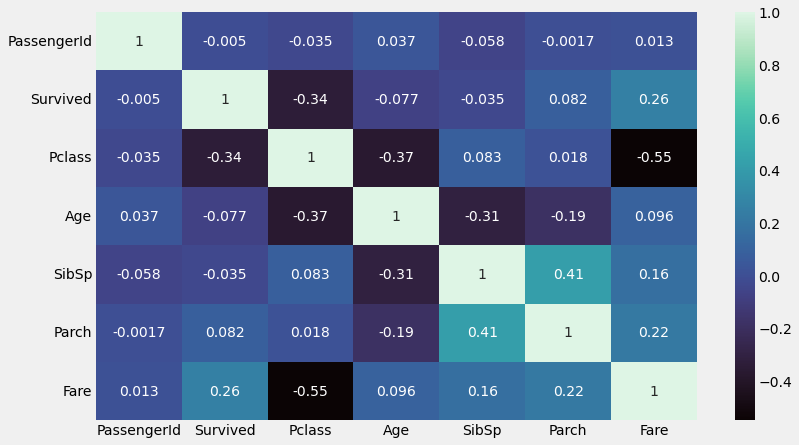

In [11]:
plt.figure(figsize=(12,7))
sns.heatmap(training.corr(), cmap='mako', annot=True, cbar=True)
#plt.title("Relationships between titanic variables")
plt.show()

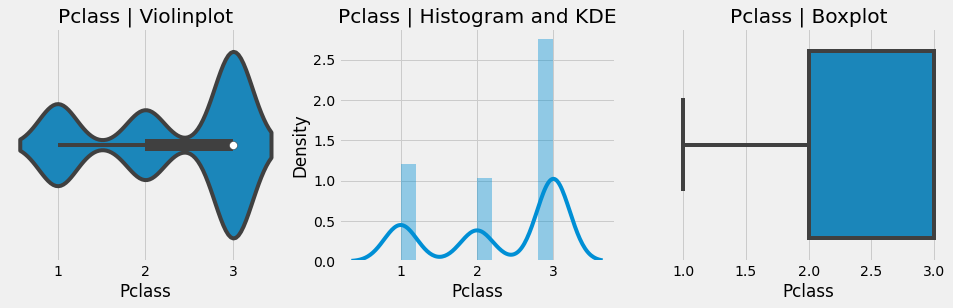

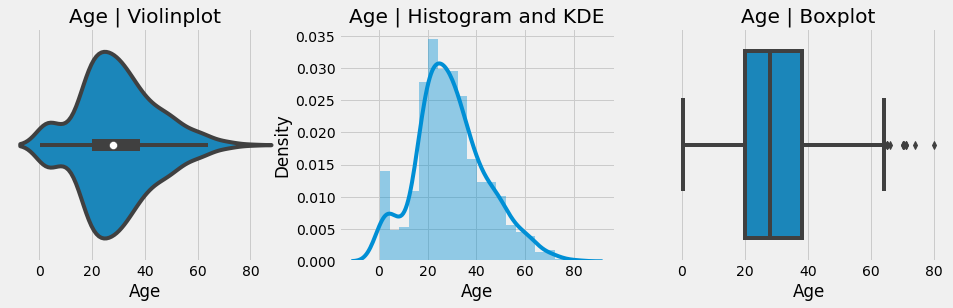

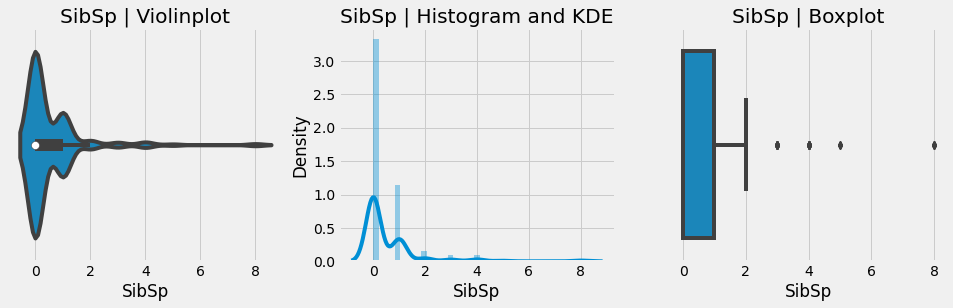

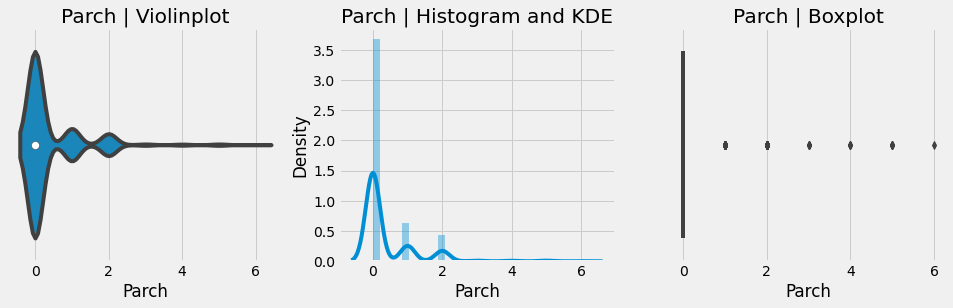

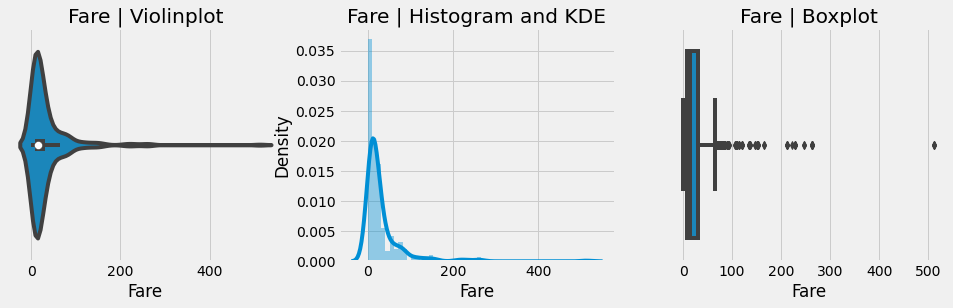

In [12]:
#collecting numeric variables for univariate analysis

var = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

for feature in training[var].columns:
    fig, axes = plt.subplots(1,3, figsize=(15,4))
    sns.violinplot(training[feature], ax =axes[0])
    sns.distplot(training[feature], ax=axes[1])
    sns.boxplot(training[feature], ax=axes[2])
    
    axes[0].set_title(feature+" | Violinplot")
    axes[1].set_title(feature+" | Histogram and KDE")
    axes[2].set_title(feature+" | Boxplot")
    


# 4. Preparation for Machine Learning models

Before we apply ML models to the data, firstly we have to make it 'ready' for the models i.e. taking measures to ensure that the models run without any error.

> Firstly we'll make a copy of both datasets as a backup

In [13]:
train_copy = training.copy()
test_copy = testing.copy()

**4.1. Feature Selection:**
> Moving forward with the some features which are necessary to make predictions, accessory features (for the sake of ML models) will be omitted. This step will increase efficiency and accuracy and decrease the chance of possible errors afterwards.

In [14]:
selected_features =["Pclass", "male","female", "SibSp", "Parch"]

**4.2. Using One-hot encoding on categorical data:**

In [15]:
def hot_encoding(df):
    hot_encoded = pd.get_dummies(df.Sex)
    df = pd.concat([df, hot_encoded], axis=1) #column binding
    df.drop('Sex', inplace=True, axis=1)
    return df

training = hot_encoding(training)
testing = hot_encoding(testing)

**4.3. Splitting the datasets in X(inputs) and y(outputs):**

In [16]:
y = training.Survived
X = training[selected_features]

test_X = testing[selected_features]

**4.4. Split training set in train and validation set:**
> Split data into training and validation data, for both features and target the split is based on a random number generator. Supplying a numeric value to the random_state argument guarantees we get the same split every time we run this script.


In [17]:
from sklearn.model_selection import train_test_split
train_X,val_X, train_y, val_y = train_test_split(X, y, random_state=1)

# 5. Machine Learning Models

For every model, we will repeatedly use these steps:
* Specify model
* Fit model on Training data
* Predict its mean absolute error using Validation data
* Saving MAE in the dictionary for model comparison

<div style="background-color:#B1a62e;
            padding:5px;
            font-size:20px;
            color:white;
            ">
    <b>5.1. Logistic Regression model</b></div>

In [18]:
#creating a dictionary to compare mean absolute error for every model used.
dict_mae={}

from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression() #specify model
lr_model.fit(train_X, train_y) #fit model

from sklearn.metrics import mean_absolute_error
validation_prediction = lr_model.predict(val_X) #predicting mae for validation data

dict_mae["Logistic Regression"]= mean_absolute_error(validation_prediction, val_y)
mean_absolute_error(validation_prediction, val_y) #printing mae

0.21973094170403587

<div style="background-color:#B1a62e;
            padding:5px;
            font-size:20px;
            color:white;
            ">
    <b>5.2. Random forest classification model</b></div>

In [19]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1) #specify model
rf_model.fit(train_X, train_y) #fit model

RandomForestClassifier(max_depth=5, random_state=1)

In [20]:
print("Making predictions for the following 5 passengers:")
print(train_X.head())
print("The predictions are")
print(rf_model.predict(train_X.head()))

Making predictions for the following 5 passengers:
     Pclass  male  female  SibSp  Parch
35        1     1       0      1      0
46        3     1       0      1      0
453       1     1       0      1      0
291       1     0       1      1      0
748       1     1       0      1      0
The predictions are
[0 0 0 1 0]


In [21]:
validation_prediction = rf_model.predict(val_X) #predicting mae for validation data

#calculating mean absolute error for random forest
print(mean_absolute_error(val_y, validation_prediction)) 
dict_mae['Random Forest']=mean_absolute_error(val_y, validation_prediction) #saving MAE in dictionary


0.2062780269058296


<div style="background-color:#B1a62e;
            padding:5px;
            font-size:20px;
            color:white;
            ">
    <b>5.3. XGBoost Classifier model</b></div>

In [22]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier() #specify model
xgb_model.fit(train_X, train_y) #fit model

validation_prediction = xgb_model.predict(val_X)
print(mean_absolute_error(val_y, validation_prediction)) #printing MAE
dict_mae['XGBoost'] = mean_absolute_error(val_y, validation_prediction) #saving MAE in dictionary


0.22869955156950672


<div style="background-color:#B1a62e;
            padding:5px;
            font-size:20px;
            color:white;
            ">
    <b>5.4. K-Nearest Neighbour Classifier model</b></div>

In [23]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5) #specify model
knn_model.fit(train_X, train_y) #fit model

validation_prediction = knn_model.predict(val_X)
print(mean_absolute_error(val_y, validation_prediction)) #printing MAE
dict_mae['K-Nearest Neighbour'] = mean_absolute_error(val_y, validation_prediction) #saving MAE in dictionary


0.24663677130044842


<div style="background-color:#B1a62e;
            padding:5px;
            font-size:20px;
            color:white;
            ">
    <b>5.5. SVM Classifier model</b></div>

In [24]:
from sklearn.linear_model import SGDRegressor

# 6. Generating results

> We will choose the model with best MAE score and afterwards, we will use the model to make actual predictions (on test data) and submit to the competition.

**6.1. Comparing the Results using best MAE:**

In [25]:
dict_mae

{'Logistic Regression': 0.21973094170403587,
 'Random Forest': 0.2062780269058296,
 'XGBoost': 0.22869955156950672,
 'K-Nearest Neighbour': 0.24663677130044842}

**6.2. Running the ML model on test Data:**

In [26]:
my_result = rf_model.predict(test_X)
# Saving the result into submission file
submission = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')
submission["Survived"] = my_result
submission.to_csv('submission.csv', index=False)  #Competition rules require that no index number be saved

<div style="background-color:#B1a62e;
            padding:5px;
            font-size:25px;
            color:white;
            text-align: center;
            ">
    <b>THAT'S ALL FOLKS!!</b></div>
    <div style="text-align: center;
    background-color:#B1a62e;
    font-size:15px;
    color:white;">If you like my work, give it a <b>thumbs up</b>. Also I am looking forward to know what you think about it. Let me know about your views in the comments bar. <b>Happy Kaggling!</b></div>
    